In [ ]:
!pip install -q datasets librosa soundfile scikit-learn xgboost joblib matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import librosa
import joblib
import matplotlib.pyplot as plt

from datasets import load_dataset, Audio
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

In [ ]:
madis = load_dataset("badrex/MADIS5-spoken-arabic-dialects")
madis

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/test-00000-of-00003.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

data/test-00001-of-00003.parquet:   0%|          | 0.00/441M [00:00<?, ?B/s]

data/test-00002-of-00003.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4854 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['segment_id', 'audio', 'dialect', 'domain', 'audio_duration'],
        num_rows: 4854
    })
})

In [ ]:
split_name = list(madis.keys())[0]
ds = madis[split_name]

print(ds.column_names)
print(ds[0])

['segment_id', 'audio', 'dialect', 'domain', 'audio_duration']
{'segment_id': 'XeNHoyXIbC', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7905624c4470>, 'dialect': 'Egyptian Arabic', 'domain': 'Theatre', 'audio_duration': 4.564}


In [ ]:
audio_col = 'audio'
label_col = 'dialect'

print("audio_col:", audio_col)
print("label_col:", label_col)

audio_col: audio
label_col: dialect


In [ ]:
print(ds.features)

{'segment_id': Value('string'), 'audio': Audio(sampling_rate=16000, decode=True, stream_index=None), 'dialect': Value('string'), 'domain': Value('string'), 'audio_duration': Value('float64')}


In [ ]:
ds = ds.cast_column(audio_col, Audio(sampling_rate=16000))

In [ ]:
labels = ds[label_col]

if hasattr(ds.features[label_col], "names"):
    label_names = ds.features[label_col].names
    labels_text = [label_names[x] for x in labels]
else:
    labels_text = labels

unique_dialects = sorted(set(labels_text))
unique_dialects

['Egyptian Arabic',
 'Gulf Arabic',
 'Levantine Arabic',
 'Maghrebi Arabic',
 'Modern Standard Arabic']

In [ ]:
TARGET_MADIS_DIALECTS = unique_dialects[:4]

TARGET_MADIS_DIALECTS

['Egyptian Arabic', 'Gulf Arabic', 'Levantine Arabic', 'Maghrebi Arabic']

In [ ]:
def keep_selected(example):
    y = example[label_col]
    if hasattr(ds.features[label_col], "names"):
        y = ds.features[label_col].names[y]
    return y in TARGET_MADIS_DIALECTS

madis_3 = ds.filter(keep_selected)
len(madis_3)

Filter:   0%|          | 0/4854 [00:00<?, ? examples/s]

4128

In [ ]:
def extract_features(audio_array, sr=16000):
    y = audio_array.astype(np.float32)

    if len(y) < sr:
        y = np.pad(y, (0, sr - len(y)))

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    features = []

    for feat in [mfcc, delta, delta2, chroma, contrast, zcr, rms]:
        features.extend(np.mean(feat, axis=1))
        features.extend(np.std(feat, axis=1))

    return np.array(features)

In [ ]:
X = []
y = []
bad_count = 0

for i, ex in enumerate(madis_3):
    try:
        audio_data = ex[audio_col]

        if audio_data is None or audio_data["array"] is None:
            bad_count += 1
            continue

        audio = audio_data["array"]
        sr = audio_data["sampling_rate"]

        if len(audio) == 0:
            bad_count += 1
            continue

        label = ex[label_col]
        if hasattr(ds.features[label_col], "names"):
            label = ds.features[label_col].names[label]

        X.append(extract_features(audio, sr))
        y.append(label)

    except Exception as e:
        bad_count += 1
        print(f"Skipped sample {i}: {e}")

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Bad samples skipped:", bad_count)

Skipped sample 945: No audio frames were decoded. This is probably because start_seconds is too high(0),or because stop_seconds(std::nullopt) is too low.
X shape: (4127, 162)
y shape: (4127,)
Bad samples skipped: 1


In [ ]:
np.save("X_madis.npy", X)
np.save("y_madis.npy", y)

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_params = {
    "knn__n_neighbors": [3, 5, 7, 9],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train, y_train)

print("Best KNN Params:")
print(knn_grid.best_params_)

best_knn = knn_grid.best_estimator_

knn_pred = best_knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred, target_names=le.classes_))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best KNN Params:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
KNN Accuracy: 0.8753026634382567
                  precision    recall  f1-score   support

 Egyptian Arabic       0.96      0.81      0.88       226
     Gulf Arabic       0.89      0.88      0.89       194
Levantine Arabic       0.85      0.91      0.88       231
 Maghrebi Arabic       0.81      0.92      0.86       175

        accuracy                           0.88       826
       macro avg       0.88      0.88      0.88       826
    weighted avg       0.88      0.88      0.88       826



In [ ]:
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [ ]:
xgb_params = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Params:")
print(xgb_grid.best_params_)

best_xgb = xgb_grid.best_estimator_

xgb_pred = best_xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best XGBoost Params:
{'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
XGBoost Accuracy: 0.9079903147699758
                  precision    recall  f1-score   support

 Egyptian Arabic       0.95      0.91      0.93       226
     Gulf Arabic       0.88      0.87      0.87       194
Levantine Arabic       0.92      0.92      0.92       231
 Maghrebi Arabic       0.88      0.93      0.91       175

        accuracy                           0.91       826
       macro avg       0.91      0.91      0.91       826
    weighted avg       0.91      0.91      0.91       826



In [ ]:
best_xgb = xgb_grid.best_estimator_

xgb_pred = best_xgb.predict(X_test)

print("Best XGBoost Params:")
print(xgb_grid.best_params_)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

Best XGBoost Params:
{'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
XGBoost Accuracy: 0.9079903147699758


In [ ]:
best_knn = knn_grid.best_estimator_
knn_pred = best_knn.predict(X_test)

print("Best KNN Params:")
print(knn_grid.best_params_)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

Best KNN Params:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
KNN Accuracy: 0.8753026634382567


In [ ]:
results = pd.DataFrame({
    "Model": ["XGBoost", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

results

,Model,Accuracy
0,XGBoost,0.907990
1,KNN,0.875303


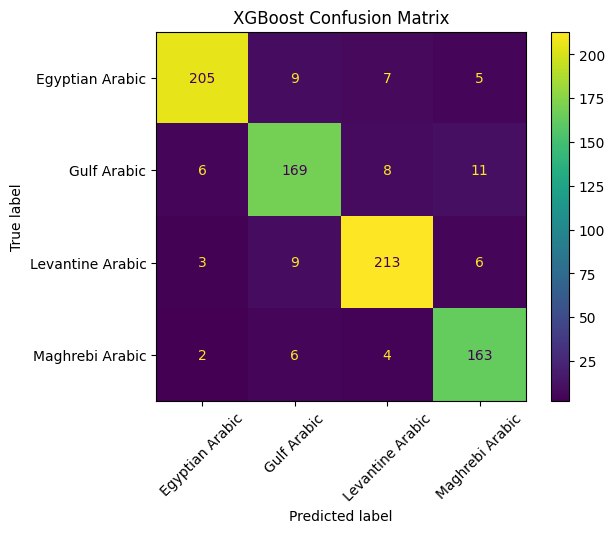

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=le.classes_,
    xticks_rotation=45
)
plt.title("XGBoost Confusion Matrix")
plt.show()

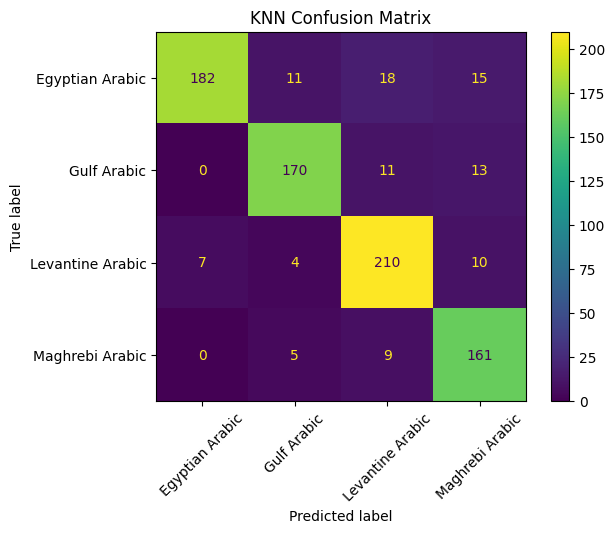

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    display_labels=le.classes_,
    xticks_rotation=45
)
plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
xgb_inner = best_xgb.named_steps["xgb"]

In [ ]:
importances = xgb_inner.feature_importances_

In [ ]:
feature_names = []

for group in ["mfcc", "delta", "delta2"]:
    for stat in ["mean", "std"]:
        for i in range(20):
            feature_names.append(f"{group}_{i+1}_{stat}")

for group, n in [("chroma", 12), ("contrast", 7), ("zcr", 1), ("rms", 1)]:
    for stat in ["mean", "std"]:
        for i in range(n):
            feature_names.append(f"{group}_{i+1}_{stat}")


In [ ]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

In [ ]:
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

In [ ]:
importance_df.head(20)

,feature,importance
101,delta2_2_std,0.034247
147,contrast_4_mean,0.030586
63,delta_4_std,0.022075
108,delta2_9_std,0.020853
11,mfcc_12_mean,0.015888
100,delta2_1_std,0.015476
3,mfcc_4_mean,0.013953
161,rms_1_std,0.013865
113,delta2_14_std,0.013610
5,mfcc_6_mean,0.013533


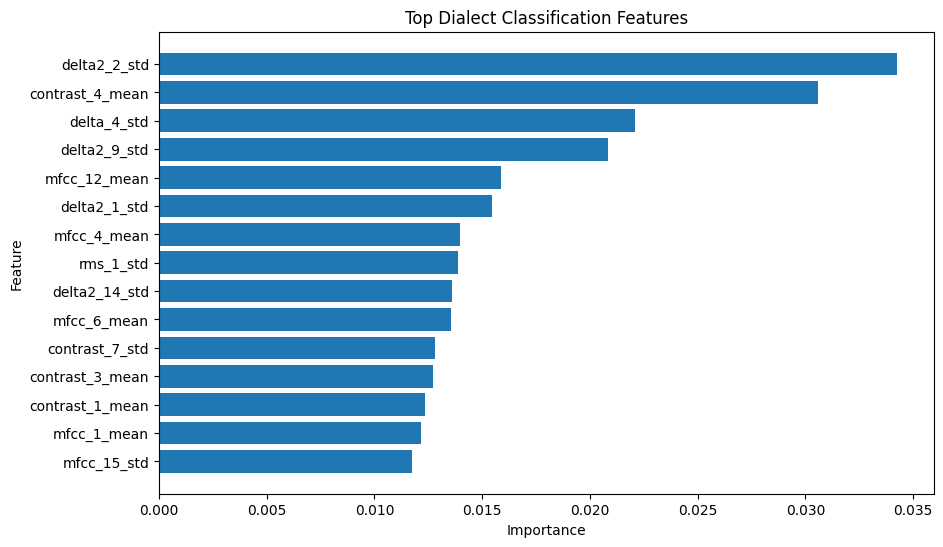

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df.head(15)["feature"][::-1],
    importance_df.head(15)["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Dialect Classification Features")

plt.show()

In [ ]:
import joblib

joblib.dump(best_xgb, "arabic_dialect_xgboost_model.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [ ]:
from google.colab import files

files.download("arabic_dialect_xgboost_model.pkl")
files.download("label_encoder.pkl")
files.download("feature_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import train_test_split
import soundfile as sf
import os
import shutil
from google.colab import files

In [ ]:
labels = []

for ex in madis_3:
    label = ex[label_col]

    if hasattr(ds.features[label_col], "names"):
        label = ds.features[label_col].names[label]

    labels.append(label)

In [ ]:
indices = list(range(len(madis_3)))

In [ ]:
_, test_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [ ]:
os.makedirs("test_audio_files", exist_ok=True)

for i, idx in enumerate(test_indices):

    ex = madis_3[idx]

    audio = ex[audio_col]["array"]
    sr = ex[audio_col]["sampling_rate"]

    label = ex[label_col]

    if hasattr(ds.features[label_col], "names"):
        label = ds.features[label_col].names[label]

    filename = f"test_audio_files/{label}_{i}.wav"

    sf.write(filename, audio, sr)

print("Saved test audio.")

Saved test audio.


In [ ]:
shutil.make_archive(
    "test_audio_files",
    'zip',
    "test_audio_files"
)

'/content/test_audio_files.zip'

In [ ]:
files.download("test_audio_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
top_features = importance_df.head(20)

top_features.to_json(
    "top_features.json",
    orient="records",
    indent=4
)

In [ ]:
from google.colab import files
files.download("top_features.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

with open("all_feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=4)

files.download("all_feature_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q umap-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from collections import Counter

In [ ]:
scaler_umap = StandardScaler()
X_train_scaled = scaler_umap.fit_transform(X_train)
X_test_scaled  = scaler_umap.transform(X_test)

print('X_train_scaled:', X_train_scaled.shape)
print('X_test_scaled :', X_test_scaled.shape)

X_train_scaled: (3301, 162)
X_test_scaled : (826, 162)


In [ ]:
from itertools import product

n_classes     = len(np.unique(y_train))
dialect_names = le.classes_

n_neighbors_opts  = [15, 20, 30]
min_dist_opts     = [0.05, 0.1, 0.2]
target_weight_opts = [0.3, 0.5, 0.7]

results = []

for nn, md, tw in product(n_neighbors_opts, min_dist_opts, target_weight_opts):
    r = umap.UMAP(
        n_components=2,
        n_neighbors=nn,
        min_dist=md,
        metric='euclidean',
        target_metric='categorical',
        target_weight=tw,
        random_state=42
    )
    r.fit(X_train_scaled, y=y_train)
    emb = r.transform(X_test_scaled)

    km  = KMeans(n_clusters=n_classes, n_init=20, random_state=42)
    cl  = km.fit_predict(emb)
    ari = adjusted_rand_score(y_test, cl)
    nmi = normalized_mutual_info_score(y_test, cl)

    results.append({
        'n_neighbors': nn, 'min_dist': md, 'target_weight': tw,
        'ARI': round(ari, 4), 'NMI': round(nmi, 4)
    })
    print(f'nn={nn:2d}  md={md}  tw={tw}  →  ARI={ari:.4f}  NMI={nmi:.4f}')

results_df = pd.DataFrame(results).sort_values('ARI', ascending=False)
print('\nTop 5 configs:')
print(results_df.head())

best = results_df.iloc[0]
print(f'\nBest → n_neighbors={int(best.n_neighbors)}, min_dist={best.min_dist}, target_weight={best.target_weight}')

nn=15  md=0.05  tw=0.3  →  ARI=0.1019  NMI=0.1296
nn=15  md=0.05  tw=0.5  →  ARI=0.1699  NMI=0.2227
nn=15  md=0.05  tw=0.7  →  ARI=0.0990  NMI=0.1129
nn=15  md=0.1  tw=0.3  →  ARI=0.1339  NMI=0.1865
nn=15  md=0.1  tw=0.5  →  ARI=0.1265  NMI=0.1496
nn=15  md=0.1  tw=0.7  →  ARI=0.1736  NMI=0.2089
nn=15  md=0.2  tw=0.3  →  ARI=0.1751  NMI=0.2433
nn=15  md=0.2  tw=0.5  →  ARI=0.1917  NMI=0.2066
nn=15  md=0.2  tw=0.7  →  ARI=0.1736  NMI=0.1863
nn=20  md=0.05  tw=0.3  →  ARI=0.1130  NMI=0.1692
nn=20  md=0.05  tw=0.5  →  ARI=0.1697  NMI=0.1871
nn=20  md=0.05  tw=0.7  →  ARI=0.3226  NMI=0.3477
nn=20  md=0.1  tw=0.3  →  ARI=0.1140  NMI=0.1522
nn=20  md=0.1  tw=0.5  →  ARI=0.1527  NMI=0.2324
nn=20  md=0.1  tw=0.7  →  ARI=0.2806  NMI=0.2788
nn=20  md=0.2  tw=0.3  →  ARI=0.0984  NMI=0.1439
nn=20  md=0.2  tw=0.5  →  ARI=0.2523  NMI=0.2697
nn=20  md=0.2  tw=0.7  →  ARI=0.2589  NMI=0.3088
nn=30  md=0.05  tw=0.3  →  ARI=0.1206  NMI=0.1609
nn=30  md=0.05  tw=0.5  →  ARI=0.1746  NMI=0.2433
nn=30  md=0.

In [ ]:
best_nn = 20
best_md = 0.05
best_tw = 0.7

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=best_nn,
    min_dist=best_md,
    metric='euclidean',
    target_metric='categorical',
    target_weight=best_tw,
    random_state=42
)

reducer.fit(X_train_scaled, y=y_train)
X_train_2d = reducer.transform(scaler_umap.transform(X_train))
X_test_2d = reducer.transform(X_test_scaled)

print('Test embedding shape:', X_test_2d.shape)

Test embedding shape: (826, 2)


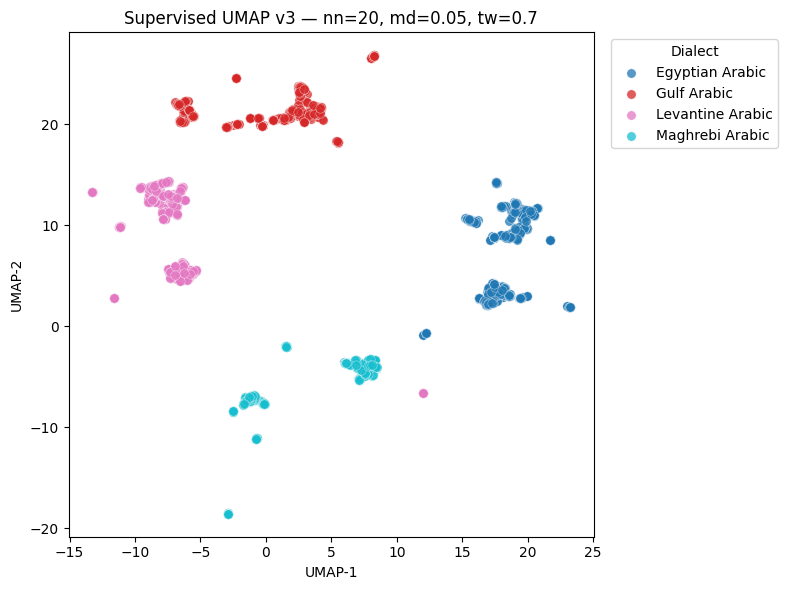

In [58]:
n_classes     = len(np.unique(y_train))
dialect_names = le.classes_

palette = plt.cm.get_cmap('tab10', n_classes)

fig, ax = plt.subplots(figsize=(8, 6))
for cls_idx, name in enumerate(dialect_names):
    mask = y_train == cls_idx
    ax.scatter(
        X_train_2d[mask, 0], X_train_2d[mask, 1],
        s=45, alpha=0.75, color=palette(cls_idx), label=name,
        edgecolors='white', linewidths=0.3
    )
ax.set_title(f'Supervised UMAP v3 — nn={best_nn}, md={best_md}, tw={best_tw}')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(title='Dialect', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('umap_v3_true_labels.png', dpi=150)
plt.show()

In [46]:
kmeans = KMeans(n_clusters=n_classes, n_init=30, random_state=42)
cluster_labels = kmeans.fit_predict(X_train_2d)

cluster_to_dialect = {}
for c in range(n_classes):
    mask     = cluster_labels == c
    majority = Counter(y_train[mask]).most_common(1)[0][0]
    cluster_to_dialect[c] = majority

print('Cluster → Dialect mapping:')
for c, d in cluster_to_dialect.items():
    print(f'  Cluster {c}  →  {dialect_names[d]}')

Cluster → Dialect mapping:
  Cluster 0  →  Levantine Arabic
  Cluster 1  →  Egyptian Arabic
  Cluster 2  →  Maghrebi Arabic
  Cluster 3  →  Gulf Arabic


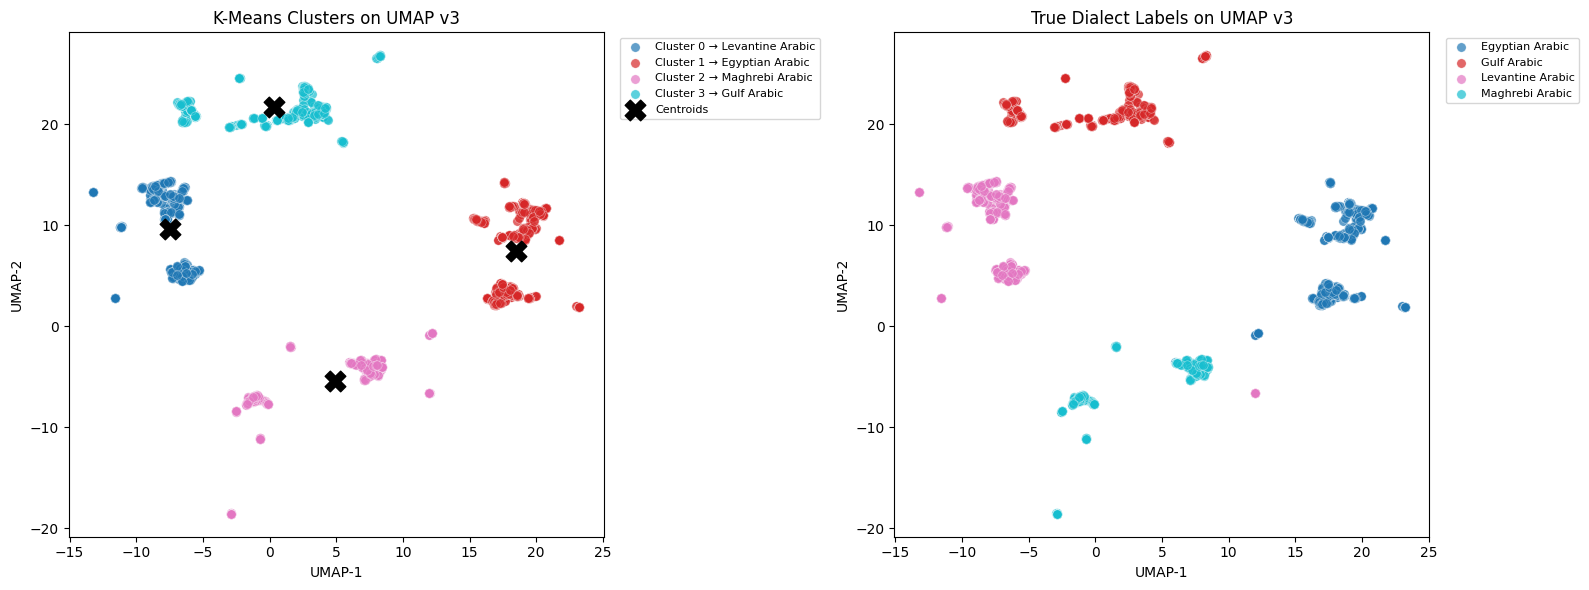

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for c in range(n_classes):
    mask = cluster_labels == c
    ax.scatter(
        X_train_2d[mask, 0], X_train_2d[mask, 1],
        s=45, alpha=0.7, color=palette(c),
        label=f'Cluster {c} → {dialect_names[cluster_to_dialect[c]]}',
        edgecolors='white', linewidths=0.3
    )
centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1],
           s=220, marker='X', c='black', zorder=5, label='Centroids')
ax.set_title('K-Means Clusters on UMAP v3')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

ax2 = axes[1]
for cls_idx, name in enumerate(dialect_names):
    mask = y_train == cls_idx
    ax2.scatter(
        X_train_2d[mask, 0], X_train_2d[mask, 1],
        s=45, alpha=0.7, color=palette(cls_idx), label=name,
        edgecolors='white', linewidths=0.3
    )
ax2.set_title('True Dialect Labels on UMAP v3')
ax2.set_xlabel('UMAP-1'); ax2.set_ylabel('UMAP-2')
ax2.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('umap_v3_kmeans_comparison.png', dpi=150)
plt.show()

In [52]:
ari = adjusted_rand_score(y_train, cluster_labels)
nmi = normalized_mutual_info_score(y_train, cluster_labels)

print(f'Adjusted Rand Index (ARI): {ari:.4f}  (1.0 = perfect, 0 = random)')
print(f'Normalised Mutual Info (NMI): {nmi:.4f}  (1.0 = perfect, 0 = random)')

Adjusted Rand Index (ARI): 0.9684  (1.0 = perfect, 0 = random)
Normalised Mutual Info (NMI): 0.9543  (1.0 = perfect, 0 = random)


In [54]:
rows = []
for cls_idx, name in enumerate(dialect_names):
    mask = y_train == cls_idx
    dist = Counter(cluster_labels[mask])
    row  = {'True Dialect': name}
    for c in range(n_classes):
        row[f'Cluster {c} (→ {dialect_names[cluster_to_dialect[c]]})'] = dist.get(c, 0)
    rows.append(row)

comp_df = pd.DataFrame(rows).set_index('True Dialect')
comp_df['Total'] = comp_df.sum(axis=1)
print(comp_df)

                  Cluster 0 (→ Levantine Arabic)  \
True Dialect                                       
Egyptian Arabic                                4   
Gulf Arabic                                    2   
Levantine Arabic                             907   
Maghrebi Arabic                                0   

                  Cluster 1 (→ Egyptian Arabic)  \
True Dialect                                      
Egyptian Arabic                             883   
Gulf Arabic                                   0   
Levantine Arabic                              0   
Maghrebi Arabic                               0   

                  Cluster 2 (→ Maghrebi Arabic)  Cluster 3 (→ Gulf Arabic)  \
True Dialect                                                                 
Egyptian Arabic                              18                          0   
Gulf Arabic                                   1                        770   
Levantine Arabic                             15                     

In [55]:
def predict_dialect_umap_kmeans(audio_array, sr=16000):
    """
    Predict the dialect of a new audio sample using the
    Supervised UMAP v3 + K-Means pipeline.

    Parameters
    ----------
    audio_array : np.ndarray  — raw waveform
    sr          : int         — sampling rate (default 16 000)

    Returns
    -------
    str  — predicted dialect name
    """
    feat        = extract_features(audio_array, sr)
    feat_scaled = scaler_umap.transform(feat[None, :])
    feat_2d     = reducer.transform(feat_scaled)
    cluster     = kmeans.predict(feat_2d)[0]
    return dialect_names[cluster_to_dialect[cluster]]


# Sanity check on first test sample
sample_scaled = scaler_umap.transform(X_test[0][None, :])
sample_2d     = reducer.transform(sample_scaled)
pred_cluster  = kmeans.predict(sample_2d)[0]
pred_dialect  = dialect_names[cluster_to_dialect[pred_cluster]]
true_dialect  = dialect_names[y_test[0]]

print(f'True dialect : {true_dialect}')
print(f'Predicted    : {pred_dialect}')
print(f'UMAP 2D point: {sample_2d[0]}')

True dialect : Maghrebi Arabic
Predicted    : Maghrebi Arabic
UMAP 2D point: [-0.94684505 -7.381542  ]


In [56]:
sample_scaled = scaler_umap.transform(X_test[0][None, :])
sample_2d     = reducer.transform(sample_scaled)
pred_cluster  = kmeans.predict(sample_2d)[0]
pred_dialect  = dialect_names[cluster_to_dialect[pred_cluster]]
true_dialect  = dialect_names[y_test[0]]

print(f'True dialect : {true_dialect}')
print(f'Predicted    : {pred_dialect}')
print(f'UMAP 2D point: {sample_2d[0]}')

True dialect : Maghrebi Arabic
Predicted    : Maghrebi Arabic
UMAP 2D point: [-0.94684505 -7.381542  ]


In [57]:
# ============================================================
# Run this ONCE in the notebook after Cell 6 (KMeans is fitted)
# It saves all artifacts needed by the backend.
# ============================================================

import joblib
import numpy as np
import os

MODELS_DIR = "models"   # change to your path if needed
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Save the three fitted objects ────────────────────────────
joblib.dump(scaler_umap,          f"{MODELS_DIR}/umap_scaler.pkl")
joblib.dump(reducer,              f"{MODELS_DIR}/umap_reducer.pkl")
joblib.dump(kmeans,               f"{MODELS_DIR}/umap_kmeans.pkl")

# ── Save the cluster → dialect mapping and label encoder ─────
joblib.dump(cluster_to_dialect,   f"{MODELS_DIR}/umap_cluster_to_dialect.pkl")
# label_encoder (le) is already saved as label_encoder.pkl — no need to re-save

# ── Save the training 2D embeddings for the background scatter
np.save(f"{MODELS_DIR}/X_train_2d.npy", X_train_2d)     # the UMAP-projected training set
np.save(f"{MODELS_DIR}/y_train.npy",    y_train)         # integer labels

print("Saved:")
print(f"  {MODELS_DIR}/umap_scaler.pkl")
print(f"  {MODELS_DIR}/umap_reducer.pkl")
print(f"  {MODELS_DIR}/umap_kmeans.pkl")
print(f"  {MODELS_DIR}/umap_cluster_to_dialect.pkl")
print(f"  {MODELS_DIR}/X_train_2d.npy")
print(f"  {MODELS_DIR}/y_train.npy")

Saved:
  models/umap_scaler.pkl
  models/umap_reducer.pkl
  models/umap_kmeans.pkl
  models/umap_cluster_to_dialect.pkl
  models/X_train_2d.npy
  models/y_train.npy


,Test Index,True Dialect,Predicted Dialect,Cluster,Correct
0,780,Egyptian Arabic,Egyptian Arabic,1,True
1,493,Egyptian Arabic,Levantine Arabic,0,False
2,448,Egyptian Arabic,Egyptian Arabic,1,True
3,31,Maghrebi Arabic,Maghrebi Arabic,2,True
4,561,Levantine Arabic,Gulf Arabic,3,False
5,248,Gulf Arabic,Levantine Arabic,0,False
6,705,Egyptian Arabic,Egyptian Arabic,1,True
7,84,Maghrebi Arabic,Maghrebi Arabic,2,True
8,675,Levantine Arabic,Levantine Arabic,0,True
9,225,Gulf Arabic,Gulf Arabic,3,True


Random sample accuracy: 70.00%


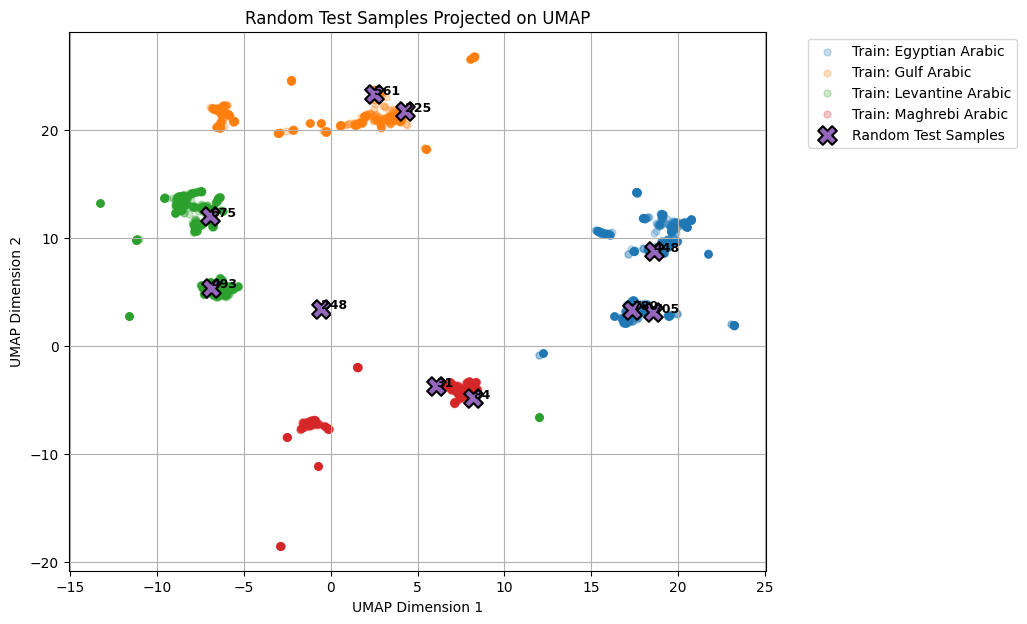

In [60]:
# ============================================================
# Random Test Samples on UMAP
# Picks random samples from X_test, projects them on UMAP,
# predicts their cluster/dialect, and plots them over the train map
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Change this number if you want more/less random samples
n_random_samples = 10

# Pick random test sample indices
random_indices = np.random.choice(
    len(X_test),
    size=min(n_random_samples, len(X_test)),
    replace=False
)

# Get the selected test samples
X_random = X_test[random_indices]
y_random_true = y_test[random_indices]

# Scale them using the same scaler used for UMAP
X_random_scaled = scaler_umap.transform(X_random)

# Project them into the same UMAP space
X_random_2d = reducer.transform(X_random_scaled)

# Predict clusters using KMeans
random_clusters = kmeans.predict(X_random_2d)

# Convert predicted clusters to dialect labels
y_random_pred = np.array([
    cluster_to_dialect[c] for c in random_clusters
])

# Create results table
results_random_umap = pd.DataFrame({
    "Test Index": random_indices,
    "True Dialect": [dialect_names[y] for y in y_random_true],
    "Predicted Dialect": [dialect_names[y] for y in y_random_pred],
    "Cluster": random_clusters,
    "Correct": y_random_true == y_random_pred
})

display(results_random_umap)

# Accuracy on these random samples only
random_accuracy = np.mean(y_random_true == y_random_pred)
print(f"Random sample accuracy: {random_accuracy:.2%}")

# ============================================================
# Plot random test samples on top of the UMAP training map
# ============================================================

plt.figure(figsize=(9, 7))

# Plot training UMAP points in the background
for cls_idx, name in enumerate(dialect_names):
    mask = y_train == cls_idx
    plt.scatter(
        X_train_2d[mask, 0],
        X_train_2d[mask, 1],
        s=25,
        alpha=0.25,
        label=f"Train: {name}"
    )

# Plot random test samples
plt.scatter(
    X_random_2d[:, 0],
    X_random_2d[:, 1],
    s=180,
    marker="X",
    edgecolor="black",
    linewidth=1.5,
    label="Random Test Samples"
)

# Add sample numbers beside points
for i, idx in enumerate(random_indices):
    plt.text(
        X_random_2d[i, 0],
        X_random_2d[i, 1],
        str(idx),
        fontsize=9,
        fontweight="bold"
    )

plt.title("Random Test Samples Projected on UMAP")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()